In [1]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json

from chars import greek, phys # a list of useful unicode chars

In [2]:
cwd = Path(os.getcwd())
results_dir = cwd / "WS2_Grating_Eamonn" / "Results"
results_dir.mkdir(exist_ok=True)

project_folder = results_dir / 'ALPHA WS₂, SiO₂, Si 1'
json_path = project_folder / 'summary_alpha.json'

with open(json_path, 'r') as file:
    data = json.load(file)
    
data_df = pd.DataFrame(data)
print(data_df.head())
data_df.info()



                                                   0.4000  \
0.0100  {'0.7000': {'0.0000': [0.4691390317607265, 0.5...   
0.0200  {'0.7000': {'0.0000': [1.0, 0.971008268776204,...   
0.0300  {'0.7000': {'0.0000': [1.0, 0.9988054553106104...   
0.0400  {'0.7000': {'0.0000': [0.9805803234460057, 0.9...   
0.0500  {'0.7000': {'0.0000': [0.8696840394780544, 0.9...   

                                                   0.5000  \
0.0100  {'0.7000': {'0.0000': [1.0, 0.9717044207379012...   
0.0200  {'0.7000': {'0.0000': [1.0, 0.9971237667014227...   
0.0300  {'0.7000': {'0.0000': [1.0, 0.9963242017166156...   
0.0400  {'0.7000': {'0.0000': [1.0, 0.9848000404633469...   
0.0500  {'0.7000': {'0.0000': [0.9968627803756752, 1.0...   

                                                   0.6000  \
0.0100  {'0.7000': {'0.0000': [1.0, 0.9796100328264912...   
0.0200  {'0.7000': {'0.0000': [0.9854575892784954, 0.9...   
0.0300  {'0.7000': {'0.0000': [0.9933120587081871, 0.9...   
0.0400  {'0.7000': {'0

In [7]:
# period, thickness, filling    units micron where appliacable
choose: List[float] = [0.7, 0.04, 0.7]

choose_str = [f"{s:.4f}" for s in choose]
print(choose_str)

alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
print(len(alpha_layer))

x_axis_str = list(alpha_layer.keys())

x_axis = [float(val) for val in x_axis_str]
print(x_axis)
y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T
y_data

df_reflectivity = pd.DataFrame(y_data)
df_reflectivity.columns = x_axis
df_reflectivity.index = np.linspace(2.2, 1.2, len(df_reflectivity.index))
df_reflectivity.head()




['0.7000', '0.0400', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]


,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
2.200000,0.997680,0.997756,0.997982,0.998369,0.998913,0.999624,1.000000,1.000000,1.000000,1.000000,...,0.956591,0.954626,0.954996,0.956900,0.959488,0.963058,0.965765,0.967968,0.967982,0.966728
2.194975,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999506,0.998494,0.997388,0.996268,...,0.968261,0.967030,0.967673,0.969607,0.972255,0.975636,0.978434,0.980891,0.981477,0.981058
2.189950,0.997461,0.997384,0.997150,0.996763,0.996211,0.995508,0.994160,0.992189,0.990082,0.988015,...,0.978530,0.977879,0.978645,0.980431,0.982883,0.985789,0.988294,0.990604,0.991374,0.991463
2.184925,0.990165,0.990010,0.989544,0.988783,0.987691,0.986322,0.984177,0.981349,0.978411,0.975647,...,0.987117,0.986871,0.987610,0.989093,0.991132,0.993335,0.995223,0.997024,0.997586,0.997813
2.179899,0.978168,0.977939,0.977250,0.976142,0.974547,0.972580,0.969737,0.966210,0.962672,0.959530,...,0.993542,0.993526,0.994110,0.995166,0.996622,0.997965,0.998988,0.999990,1.000000,1.000000


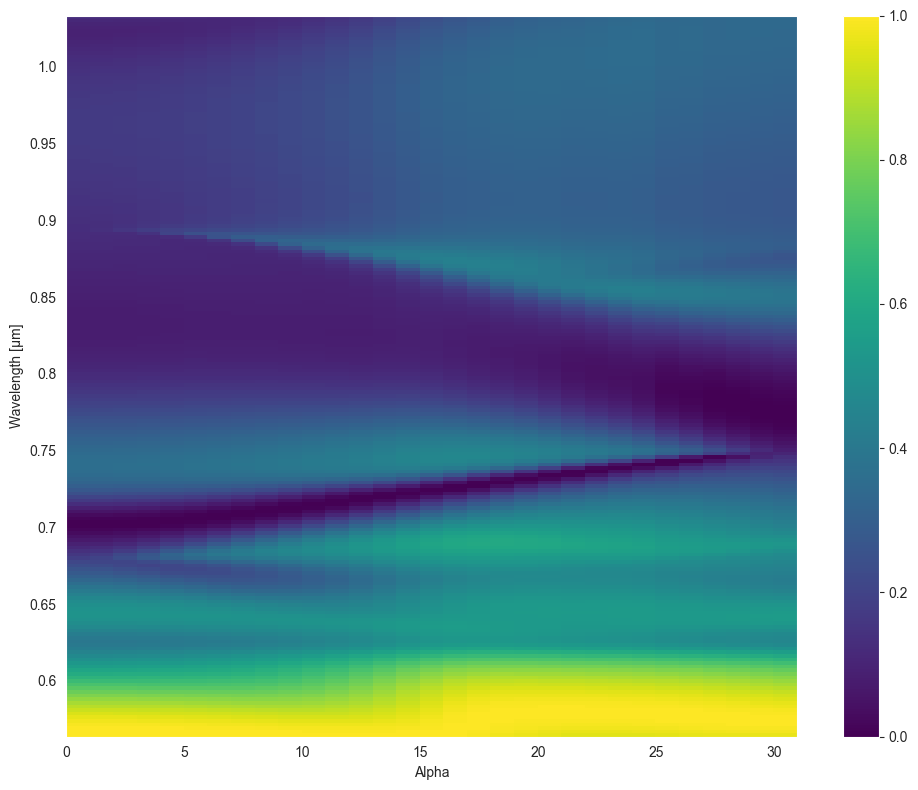

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing code to prepare the data
df_reflec_wave = df_reflectivity.copy()
df_reflec_wave.index = 1.24/df_reflectivity.index
df_reflec_wave = df_reflec_wave.sort_index(ascending=False)
df_cropped = df_reflec_wave
df_cropped = df_cropped.loc[:, :]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(df_cropped, cmap='viridis', aspect='auto', extent=[0, df_cropped.shape[1], df_cropped.index.min(), df_cropped.index.max()])

# Generate tick labels with 0.05 increments
yticklabels = np.round(np.arange(0.55, 1.05, 0.05), 2)
yticks = np.interp(yticklabels, df_cropped.index, range(len(df_cropped)))

# Set the new tick locations and labels
ax.set_yticks(yticklabels)
ax.set_yticklabels(yticklabels)

# Remove gridlines
ax.grid(False)

# Remove extra y scale
ax.set_ylim(df_cropped.index.min(), df_cropped.index.max())

# Add colorbar
plt.colorbar(im)

ax.set_xlabel("Alpha")
ax.set_ylabel("Wavelength [μm]")

plt.tight_layout()
plt.show()


In [39]:
alpha_layer = data[choose_str[0]]['0.0100']['0.7000'].keys()
alpha_layer

dict_keys(['0.0000', '0.0100', '0.0200', '0.0300', '0.0400', '0.0500', '0.0600', '0.0700', '0.0800', '0.0900', '0.1000', '0.1100', '0.1200', '0.1300', '0.1400', '0.1500', '0.1600', '0.1700', '0.1800', '0.1900', '0.2000', '0.2100', '0.2200', '0.2300', '0.2400', '0.2500', '0.2600', '0.2700', '0.2800', '0.2900', '0.3000'])

['0.7000', '0.0100', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]
SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ALPHA WS₂, SiO₂, Si 1/Wavelength vs Alpha - 0.7 0.01 0.7.png


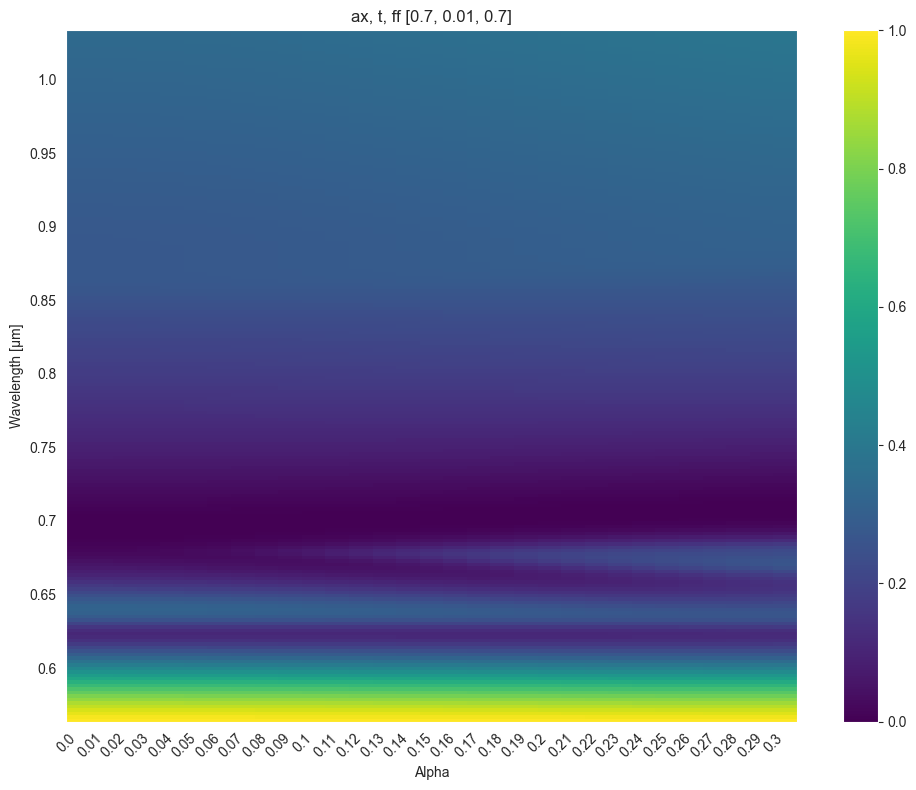

['0.7000', '0.0200', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]
SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ALPHA WS₂, SiO₂, Si 1/Wavelength vs Alpha - 0.7 0.02 0.7.png


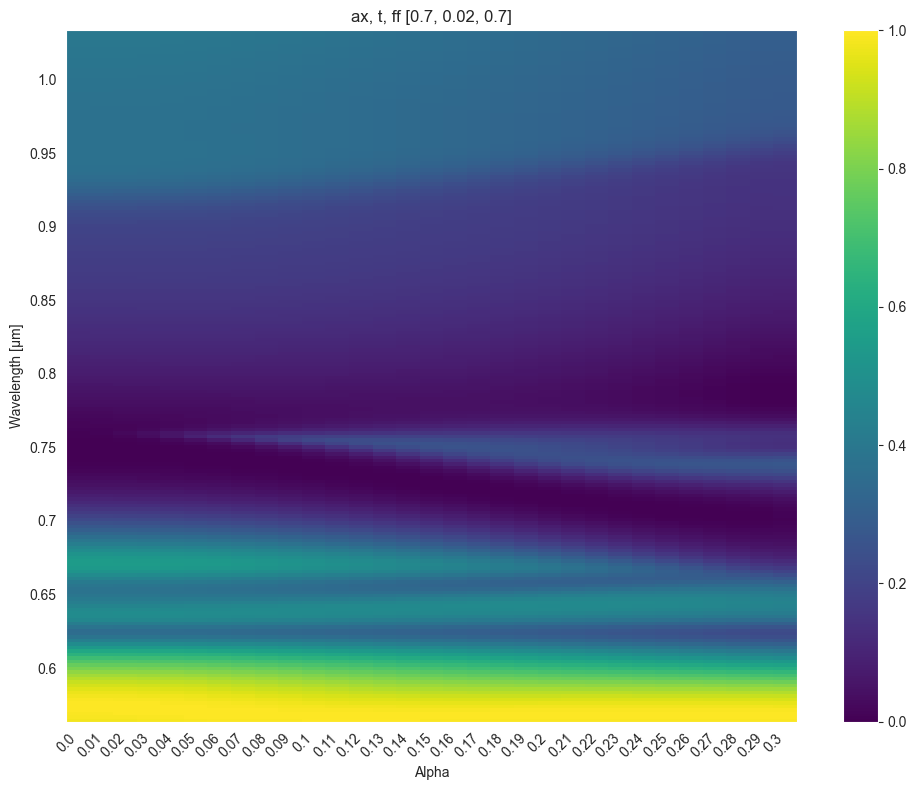

['0.7000', '0.0300', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]
SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ALPHA WS₂, SiO₂, Si 1/Wavelength vs Alpha - 0.7 0.03 0.7.png


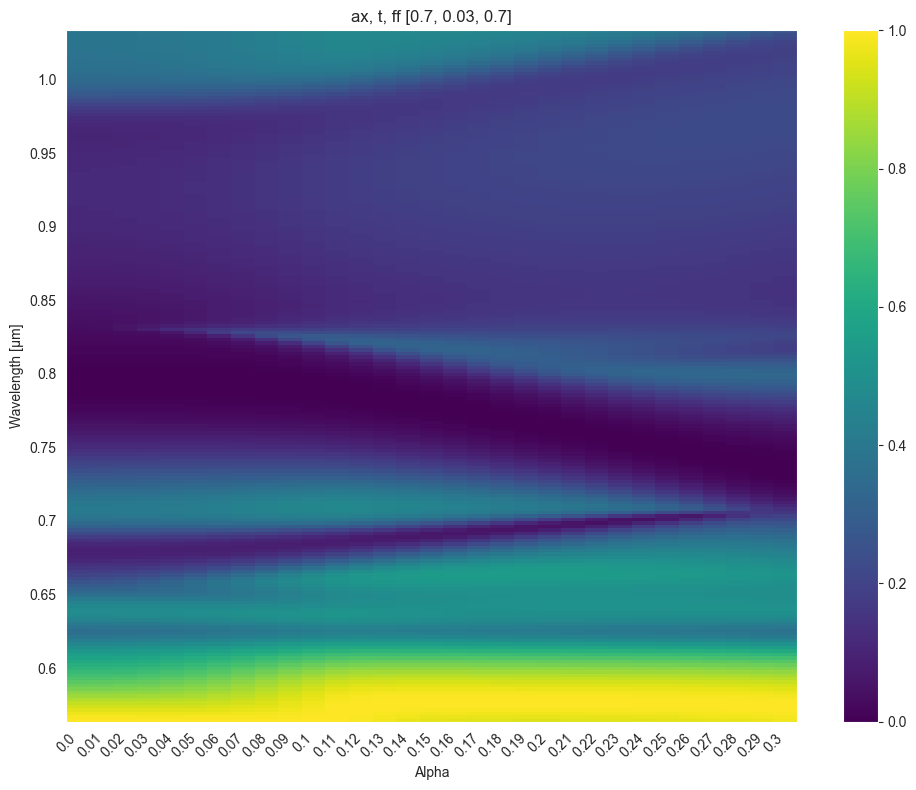

['0.7000', '0.0400', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]
SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ALPHA WS₂, SiO₂, Si 1/Wavelength vs Alpha - 0.7 0.04 0.7.png


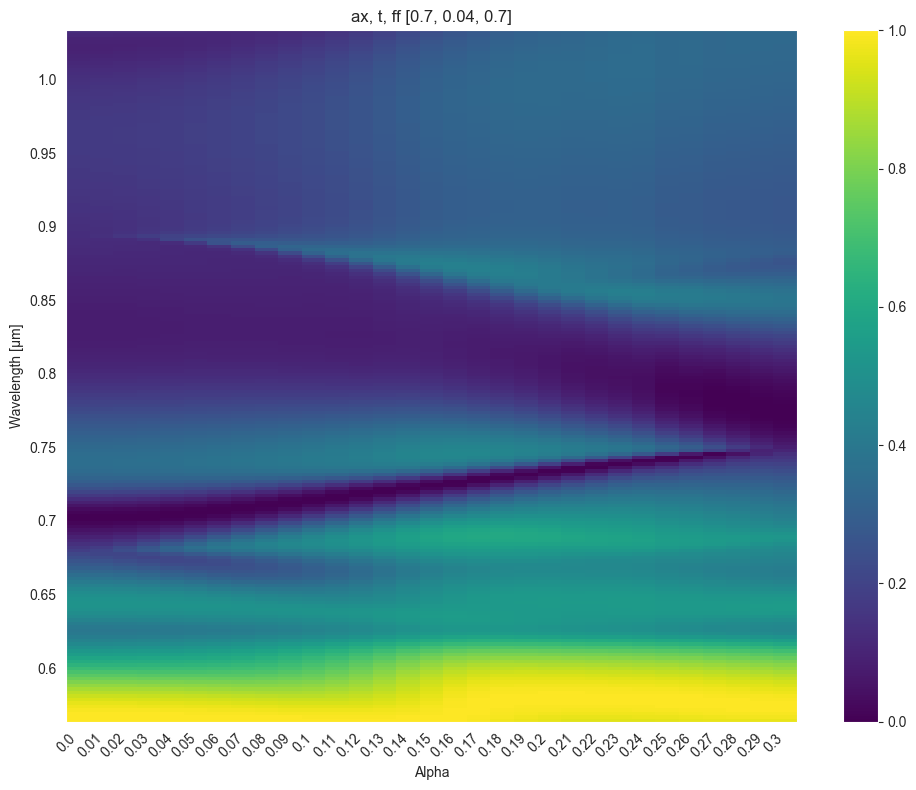

['0.7000', '0.0500', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]
SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ALPHA WS₂, SiO₂, Si 1/Wavelength vs Alpha - 0.7 0.05 0.7.png


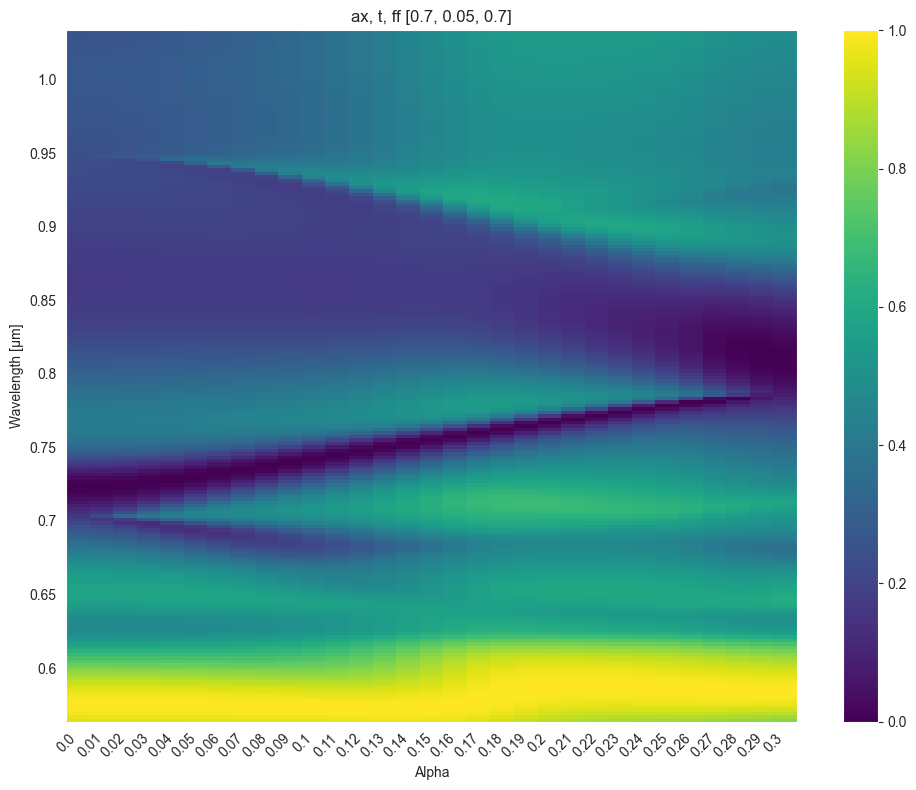

In [60]:
params = [0.01, 0.02, 0.03, 0.04, 0.05]

for p in params:
    # period, thickness, filling    units micron where appliacable
    choose: List[float] = [0.7, p, 0.7]
    
    choose_str = [f"{s:.4f}" for s in choose]
    print(choose_str)
    
    alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
    print(len(alpha_layer))
    
    x_axis_str = list(alpha_layer.keys())
    
    x_axis = [float(val) for val in x_axis_str]
    print(x_axis)
    
    y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T
    
    df_reflectivity = pd.DataFrame(y_data)
    df_reflectivity.columns = x_axis
    df_reflectivity.index = np.linspace(2.2, 1.2, len(df_reflectivity.index))
    df_reflectivity.head()
    
    
    df_reflec_wave = df_reflectivity.copy()
    df_reflec_wave.index = 1.24/df_reflectivity.index
    df_reflec_wave = df_reflec_wave.sort_index(ascending=False)
    df_cropped = df_reflec_wave
    df_cropped = df_cropped.loc[:, :]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(df_cropped, cmap='viridis', aspect='auto', extent=[0, df_cropped.shape[1], df_cropped.index.min(), df_cropped.index.max()])
    
    # Generate tick labels with 0.05 increments
    yticklabels = np.round(np.arange(0.55, 1.05, 0.05), 2)
    yticks = np.interp(yticklabels, df_cropped.index, range(len(df_cropped)))
    
    # Set the new tick locations and labels
    ax.set_yticks(yticklabels)
    ax.set_yticklabels(yticklabels)
    
    
    # Set x-axis ticks and labels
    n_xticks = len(x_axis)
    xticks = np.linspace(0, n_xticks - 1, n_xticks)
    xticklabels = np.round(x_axis, 2)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    
    
    # Remove gridlines
    ax.grid(False)
    
    # Remove extra y scale
    ax.set_ylim(df_cropped.index.min(), df_cropped.index.max())
    
    # Add colorbar
    plt.colorbar(im)
    
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Wavelength [μm]")
    
    ax.set_title(f"ax, t, ff {choose}")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    choose_str_1 = 'Wavelength vs Alpha -'
    for s in choose:
        choose_str_1 += f' {s}'
    choose_str_1 += '.png'
    
    image_path = project_folder / choose_str_1
    plt.savefig(image_path, dpi=300)
    print(f"SAVED IMAGE TO {image_path}")
    
    plt.show()
    
